In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [ ]:
SEMILLA = 2026
np.random.seed(SEMILLA)

In [ ]:
import pandas as pd

url_pm25 = "https://raw.githubusercontent.com/trajano-carballo/paa-pronostico-pm25-montevideo/main/data/processed/pm25_horario_preprocesado.csv"
df = pd.read_csv(url_pm25, parse_dates=["timestamp"], index_col="timestamp")

print(f'{len(df)} filas · {df.shape[1]} columnas')
print('Particiones:', df.particion.value_counts().to_dict())
df.head()

24504 filas · 9 columnas
Particiones: {'entrenamiento': 17544, 'validacion_temporal': 3480, 'validacion_espacial': 3480}


,pm25,completitud_observada,estacion,fuera_rango_valido,hora,dia_semana,mes,evaluable,particion
timestamp,,,,,,,,,
2024-01-01 00:00:00-03:00,42.783333,1.0,Curva de Maroñas,False,0,0,1,True,entrenamiento
2024-01-01 01:00:00-03:00,11.166667,1.0,Curva de Maroñas,False,1,0,1,True,entrenamiento
2024-01-01 02:00:00-03:00,7.500000,1.0,Curva de Maroñas,False,2,0,1,True,entrenamiento
2024-01-01 03:00:00-03:00,7.166667,1.0,Curva de Maroñas,False,3,0,1,True,entrenamiento
2024-01-01 04:00:00-03:00,3.000000,1.0,Curva de Maroñas,False,4,0,1,True,entrenamiento


In [ ]:
# 4.1 — Separación por estación y matrices supervisadas
maronas = df[df.estacion.str.contains('Maroñas')].sort_index()   # entrenamiento + validacion_temporal
museo   = df[df.estacion.str.contains('Museo')].sort_index()     # validacion_espacial

# Chequeo de continuidad horaria (los lags lo exigen)
for nombre, d in [('Maroñas', maronas), ('Museo', museo)]:
    esperado = pd.date_range(d.index.min(), d.index.max(), freq='h')
    print(f'{nombre}: {len(d)} filas, {len(esperado)} horas esperadas, '
          f'{d.index.min()} → {d.index.max()}, evaluables={d.evaluable.sum()}')

Maroñas: 21024 filas, 21024 horas esperadas, 2024-01-01 00:00:00-03:00 → 2026-05-25 23:00:00-03:00, evaluables=19772
Museo: 3480 filas, 3480 horas esperadas, 2026-01-01 00:00:00-03:00 → 2026-05-25 23:00:00-03:00, evaluables=3451


In [ ]:
# 4.1b — Matrices supervisadas
LAGS = [1, 2, 3, 24, 48]   # fijados con ACF/PACF (punto 8.3 del preprocesamiento)
HORIZONTE = 24

def preparar_xy(d, lags=LAGS, horizonte=HORIZONTE):
    """X = lags; Y = targets t+1..t+h; EV = evaluabilidad del target;
    P = persistencia estacional (misma hora del día anterior)."""
    d = d.sort_index().asfreq('h')
    s, ev = d['pm25'], d['evaluable'].fillna(False).astype(bool)
    X  = pd.DataFrame({f'lag_{l}': s.shift(l) for l in lags}, index=d.index)
    Y  = pd.DataFrame({f'h{h}': s.shift(-h) for h in range(1, horizonte+1)}, index=d.index)
    EV = pd.DataFrame({f'h{h}': ev.shift(-h) for h in range(1, horizonte+1)},
                  index=d.index).astype('boolean').fillna(False)
    P  = pd.DataFrame({f'h{h}': s.shift(24-h) for h in range(1, horizonte+1)}, index=d.index)
    return X, Y, EV, P

def mask_h(X, Y, EV, P, h, desde=None, hasta=None):
    """Filas usables para el horizonte h: lags completos, target real y evaluable."""
    m = X.notna().all(axis=1) & Y[f'h{h}'].notna() & EV[f'h{h}'] & P[f'h{h}'].notna()
    tz = X.index.tz   # los timestamps son tz-aware (America/Montevideo)
    if desde is not None: m &= X.index >= pd.Timestamp(desde, tz=tz)
    if hasta is not None: m &= X.index <= pd.Timestamp(hasta, tz=tz)
    return m

X_m, Y_m, EV_m, P_m = preparar_xy(maronas)
for h in [1, 12, 24]:
    print(f'h={h:>2} | train: {mask_h(X_m,Y_m,EV_m,P_m,h,"2024-01-01","2025-12-31 23:00").sum():>6} '
          f'| val. temporal: {mask_h(X_m,Y_m,EV_m,P_m,h,"2026-01-01","2026-05-25 23:00").sum():>5}')

h= 1 | train:  16248 | val. temporal:  3475
h=12 | train:  16248 | val. temporal:  3464
h=24 | train:  16248 | val. temporal:  3452


In [ ]:
# 4.2 — Backtesting con ventana expansiva sobre 2024-2025 (Maroñas)
from sklearn.compose import TransformedTargetRegressor

def nuevo_modelo():
    # SGD es sensible a la escala; el scaler se ajusta solo con el train de cada corte
    base = make_pipeline(
        StandardScaler(),
        SGDRegressor(loss='squared_error', penalty='l2', max_iter=5000,
                     tol=1e-4, random_state=SEMILLA))
    return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

CORTES = [  # (fin_train, inicio_test, fin_test); el train siempre arranca en 2024-01-01
    ('2024-12-31 23:00', '2025-01-01', '2025-03-31 23:00'),
    ('2025-03-31 23:00', '2025-04-01', '2025-06-30 23:00'),
    ('2025-06-30 23:00', '2025-07-01', '2025-09-30 23:00'),
    ('2025-09-30 23:00', '2025-10-01', '2025-12-31 23:00'),
]

def evaluar(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'n': len(y_true)}

filas = []
for i, (fin_tr, ini_te, fin_te) in enumerate(CORTES, start=1):
    for h in range(1, HORIZONTE + 1):
        m_tr = mask_h(X_m, Y_m, EV_m, P_m, h, '2024-01-01', fin_tr)
        m_te = mask_h(X_m, Y_m, EV_m, P_m, h, ini_te, fin_te)
        if m_tr.sum() < 100 or m_te.sum() == 0:
            continue
        mod = nuevo_modelo().fit(X_m[m_tr], Y_m.loc[m_tr, f'h{h}'])
        y_true = Y_m.loc[m_te, f'h{h}']
        filas.append({'corte': i, 'horizonte': h, 'modelo': 'SGD',
                      **evaluar(y_true, mod.predict(X_m[m_te]))})
        filas.append({'corte': i, 'horizonte': h, 'modelo': 'persistencia',
                      **evaluar(y_true, P_m.loc[m_te, f'h{h}'])})

bt = pd.DataFrame(filas)
print(bt.shape, '— cortes:', sorted(bt.corte.unique()))

(192, 6) — cortes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,MAE,RMSE,n
modelo,,,
SGD,10.634,18.652,196080.0
persistencia,11.211,23.219,196080.0


MAE                 RMSE             
modelo        SGD persistencia     SGD persistencia
horizonte                                          
1           7.417       11.356  14.915       23.406
2           8.883       11.357  17.266       23.406
3           9.975       11.361  18.601       23.414
4          10.702       11.365  19.033       23.424
5          11.109       11.370  19.379       23.436
6          11.351       11.374  19.508       23.449
7          11.384       11.378  19.532       23.463
8          11.311       11.383  19.510       23.477
9          11.396       11.387  19.554       23.492
10         11.347       11.392  19.489       23.506
11         11.559       11.396  19.616       23.520
12         11.539       11.400  19.596       23.534
13         11.452       11.405  19.548       23.549
14         11.476       11.409  19.551       23.565
15         11.407       11.415  19.568       23.582
16         11.187       11.420  19.443       23.600
17         10.902       11.425  19.395       23.619
18         10.760       11.430  19.191       23.640
19         10.809       11.436  18.916       23.663
20         10.452       11.443  18.694       23.686
21         10.274       11.452  18.597       23.715
22         10.280       11.461  18.540       23.747
23         10.334       11.472  18.631       23.788
24         10.454       11.480  18.722       23.816

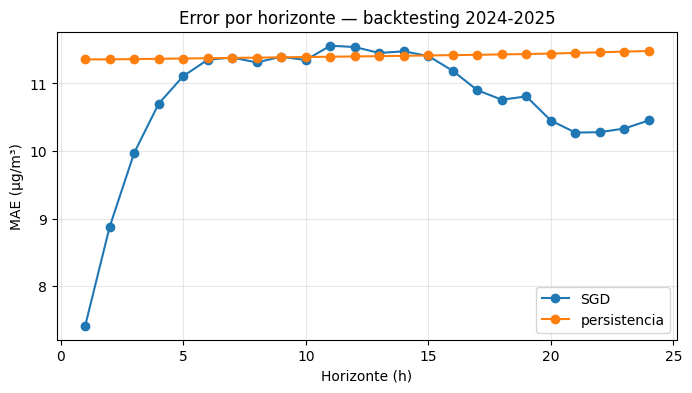

In [ ]:
# 4.3 — Métricas globales y por horizonte
def agregar(g):   # promedio ponderado por cantidad de horas evaluadas
    return pd.Series({'MAE': np.average(g.MAE, weights=g.n),
                      'RMSE': np.average(g.RMSE, weights=g.n),
                      'n': g.n.sum()})

global_bt = bt.groupby('modelo')[['MAE','RMSE','n']].apply(agregar).round(3)
por_h = bt.pivot_table(index='horizonte', columns='modelo',
                       values=['MAE', 'RMSE'], aggfunc='mean').round(3)
display(global_bt); display(por_h)

fig, ax = plt.subplots(figsize=(8, 4))
for mod in bt.modelo.unique():
    sub = bt[bt.modelo == mod].groupby('horizonte').MAE.mean()
    ax.plot(sub.index, sub.values, marker='o', label=mod)
ax.set_xlabel('Horizonte (h)'); ax.set_ylabel('MAE (µg/m³)')
ax.set_title('Error por horizonte — backtesting 2024-2025'); ax.legend(); ax.grid(alpha=.3)
plt.show()

In [ ]:
# 4.4 — Entrenamiento final y validación temporal / espacial (sin reentrenar)
modelos = {}
for h in range(1, HORIZONTE + 1):
    m_tr = mask_h(X_m, Y_m, EV_m, P_m, h, '2024-01-01', '2025-12-31 23:00')
    modelos[h] = nuevo_modelo().fit(X_m[m_tr], Y_m.loc[m_tr, f'h{h}'])

def validar(d_estacion, etiqueta, desde='2026-01-01', hasta='2026-05-25 23:00'):
    Xv, Yv, EVv, Pv = preparar_xy(d_estacion)
    out = []
    for h in range(1, HORIZONTE + 1):
        m = mask_h(Xv, Yv, EVv, Pv, h, desde, hasta)
        if m.sum() == 0:
            continue
        y_true = Yv.loc[m, f'h{h}']
        out.append({'validacion': etiqueta, 'horizonte': h, 'modelo': 'SGD',
                    **evaluar(y_true, modelos[h].predict(Xv[m]))})
        out.append({'validacion': etiqueta, 'horizonte': h, 'modelo': 'persistencia',
                    **evaluar(y_true, Pv.loc[m, f'h{h}'])})
    return pd.DataFrame(out)

val = pd.concat([validar(maronas, 'temporal (Maroñas)'),
                 validar(museo,   'espacial (Museo Romántico)')])

resumen = (val.groupby(['validacion','modelo'])[['MAE','RMSE','n']]
              .apply(agregar).round(3))
display(resumen)

MAE    RMSE        n
validacion                 modelo                              
espacial (Museo Romántico) SGD           7.596  12.233  81372.0
                           persistencia  6.208  15.373  81372.0
temporal (Maroñas)         SGD           9.387  16.280  83124.0
                           persistencia  9.307  19.986  83124.0

In [ ]:
# 4.5 — Guardado de resultados
# resumen.to_csv('resultados_linea_base.csv')
# bt.to_csv('backtesting_linea_base.csv', index=False)
# val.to_csv('validacion_2026_detalle.csv', index=False)

# from google.colab import files
# for f in ['resultados_linea_base.csv', 'backtesting_linea_base.csv', 'validacion_2026_detalle.csv']:
#     files.download(f)

# print('Guardado y descargado')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Guardado y descargado
